## Imports

In [242]:

import sys
import pandas as pd
import numpy as np
import torch
from pathlib import Path
import numpy as np
import logging
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import scanpy as sc
import muon as mu

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER")
DATA_DIR = PROJECT_DIR / "cached_data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
RESULT_DIR = PROJECT_DIR / "testing_results"

output_dir = PROJECT_DIR / "mouse_development_testing"

sys.path.append(str(PROJECT_DIR))

import warnings

if torch.cuda.is_available():
    device = torch.device("cuda")
    logging.info(f"Using GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")
else:
    device = torch.device("cpu")
    logging.info("Using CPU")

warnings.filterwarnings(
    "ignore",
    message="You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

font_path = PROJECT_DIR / "fonts" / "Arial.ttf"

fm.fontManager.addfont(font_path)
arial_font = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = [arial_font, "Helvetica", "Liberation Sans", "DejaVu Sans"]

logging.info(f"Using font: {arial_font}")

rng = np.random.default_rng()

INFO - Using CPU
INFO - Using font: Arial


## Labeling Cell Lineages


### Load Muon Data
Does the model, when trained using hepatocyte data, correctly identify lineage-specific signaling in mouse embryonic cells? To test this, I first need to load in the muon h5mu file for the sample. We will re-normalize the raw counts for getting the cell lineages.

In [243]:
def load_muon_data(cell_type, sample_name):
    mudata_path = Path(f"/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/sample_input_data/{cell_type}/{sample_name}/multiome_processed.h5mu")
    
    mudata = mu.read_h5mu(mudata_path)
    return mudata

e85_expression = load_muon_data("mESC", "E8.5_rep1")
rna = e85_expression["rna"]
rna_de = rna.copy()

# Re-normalize the raw counts
rna_de.X = rna_de.layers["counts"].copy()
sc.pp.normalize_total(rna_de,target_sum=1e4)
# sc.pp.log1p(rna_de)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


### Rank gene groups

Next we will get the marker genes between the groups, based on the `leiden` attribute.

In [244]:
sc.tl.rank_genes_groups(
    rna_de,
    groupby="leiden",
    reference="rest",
    method="wilcoxon",
    use_raw=False,
    pts=True,
    key_added="leiden_markers"
)

/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/scanpy/tools/_rank_genes_g

In [245]:
all_clusters = rna_de.obs["leiden"].unique().tolist()

# Get the top 15 markers per cluster
summary = {}
for cluster in all_clusters:
    df = sc.get.rank_genes_groups_df(
        rna_de,
        group=cluster,
        key="leiden_markers"
    ).copy()
    
    # Only return significant marker genes
    df = df[
        (df["scores"] > 0) &
        (df["pvals_adj"] < 0.05)
    ]

    # Set a specificity score based on how expressed the gene is 
    # in the cluster vs the rest of the cells
    df["specificity"] = (
        df["pct_nz_group"] - df["pct_nz_reference"]
    )

    # Combine statistical rank and specificity
    df = df.sort_values(
        ["scores", "specificity"],
        ascending=False
    )

    summary[cluster] = df["names"].head(15).tolist()
    
for cluster, genes in summary.items():
    print(f"Cluster {cluster}: {', '.join(genes)}")

Cluster 0: Kdr, Fli1, Plvap, Egfl7, Flt1, Shank3, Elk3, Igfbp4, Tek, Ramp2, Flt4, Rhoj, Arap3, Vav3, Ptprm
Cluster 1: Ptn, Mast4, Npas3, Adgrv1, Sox2ot, Car10, Ctnna2, Fgf15, Fst, Slc35f1, Zfp423, Efna5, Ptpn13, Fmn2, Epha4
Cluster 2: Rspo3, Dll1, Lef1, Smc6, Dll3, Pcdh19, Kif26b, Smoc1, Rftn1, Tmem132c, Rnf213, Mllt3, Epha4, Laptm4b, Hoxd4
Cluster 5: Hbb-bh1, Hba-x, Hba-a1, Fth1, Rplp0, Abcb10, Hba-a2, Rps9, Gpx1, Reln, Frrs1, Blvrb, Mir142hg, Sptb, Slc25a21
Cluster 6: Pmp22, Dlk1, Nrp1, Ahnak, Ece1, Igf2, Col1a2, Tmem108, Podxl, Stard8, Mest, Prdm6, Col5a2, Serpinh1, Pcdh7
Cluster 7: Wnt6, Slc2a3, Bcam, Frem2, Dag1, Epcam, Cdh3, Spint2, Npnt, Cdh1, Esrp1, Hapln1, Cldn6, F11r, Wls
Cluster 9: Otx2, Cdh20, Epha7, Irs4, Six3, Rmst, Adgrv1, Kif21a, Rgma, Lrp2, Tenm4, Tmem47, Ank2, Pcsk1n, Cdh6
Cluster 10: Fbn2, Ntn1, Pdgfra, Fst, Meis2, Foxp2, Meox1, Fbxl7, Aff3, Tcf15, Cadm1, Aldh1a2, Sdk1, Sim1, Cdh11
Cluster 11: Sfmbt2, Phlda2, Mt2, Rhox5, Gjb3, Cdh1, Trap1a, Fabp3, Mt1, Klhl13, Epcam,

### Assign cell lineages based on the marker genes

In [246]:
cluster_to_lineage = {
    "0":  "Endothelial",
    "1":  "Neural ectoderm",
    "2":  "Presomitic mesoderm",
    "3":  "Nascent/posterior mesoderm",
    "4":  "Cranial/pharyngeal mesoderm",
    "5":  "Primitive erythroid",
    "6":  "Extraembryonic mesoderm",
    "7":  "Amniotic/surface ectoderm",
    "8":  "Surface/placodal ectoderm",
    "9":  "Anterior neural ectoderm",
    "10": "Somitic/paraxial mesoderm",
    "11": "Trophoblast/extraembryonic ectoderm",
    "12": "Primitive erythroid",
    "13": "Definitive/gut endoderm",
    "14": "Posterior extraembryonic mesoderm",
    "15": "Lateral plate mesoderm",
    "16": "Midbrain-hindbrain neural ectoderm",
    "17": "Allantoic mesoderm",
    "18": "Parietal endoderm",
    "19": "Neural tube",
    "20": "NMP",
    "21": "Ventral spinal cord",
    "22": "Neural crest",
    "23": "Visceral/yolk-sac endoderm",
    "24": "Cardiomyocyte",
}

cluster_to_broad_lineage = {
    "0":  "Mesoderm",          # Endothelial
    "1":  "Ectoderm",          # Neural ectoderm
    "2":  "Mesoderm",          # Presomitic mesoderm
    "3":  "Mesoderm",          # Nascent/posterior mesoderm
    "4":  "Mesoderm",          # Cranial/pharyngeal mesoderm
    "5":  "Hematopoietic",     # Primitive erythroid
    "6":  "Extraembryonic",    # Extraembryonic mesoderm
    "7":  "Ectoderm",          # Amniotic/surface ectoderm
    "8":  "Ectoderm",          # Surface/placodal ectoderm
    "9":  "Ectoderm",          # Anterior neural ectoderm
    "10": "Mesoderm",          # Somitic/paraxial mesoderm
    "11": "Extraembryonic",    # Trophoblast/extraembryonic ectoderm
    "12": "Hematopoietic",     # Primitive erythroid
    "13": "Endoderm",          # Definitive/gut endoderm
    "14": "Extraembryonic",    # Posterior extraembryonic mesoderm
    "15": "Mesoderm",          # Lateral plate mesoderm
    "16": "Ectoderm",          # Midbrain-hindbrain neural ectoderm
    "17": "Extraembryonic",    # Allantoic mesoderm
    "18": "Extraembryonic",    # Parietal endoderm
    "19": "Ectoderm",          # Neural tube
    "20": "Ectoderm",          # NMP
    "21": "Ectoderm",          # Ventral spinal cord
    "22": "Ectoderm",          # Neural crest
    "23": "Extraembryonic",    # Visceral/yolk-sac endoderm
    "24": "Mesoderm",          # Cardiomyocyte
}

rna.obs["fine_lineage"] = (
    rna.obs["leiden"]
    .astype(str)
    .map(cluster_to_lineage)
)

rna.obs["broad_lineage"] = (
    rna.obs["leiden"]
    .astype(str)
    .map(cluster_to_broad_lineage)
)

rna.obs["fine_lineage"] = pd.Categorical(rna.obs["fine_lineage"])
rna.obs["broad_lineage"] = pd.Categorical(rna.obs["broad_lineage"])

### UMAP of labeled cell lineages

#### Fine Lineages

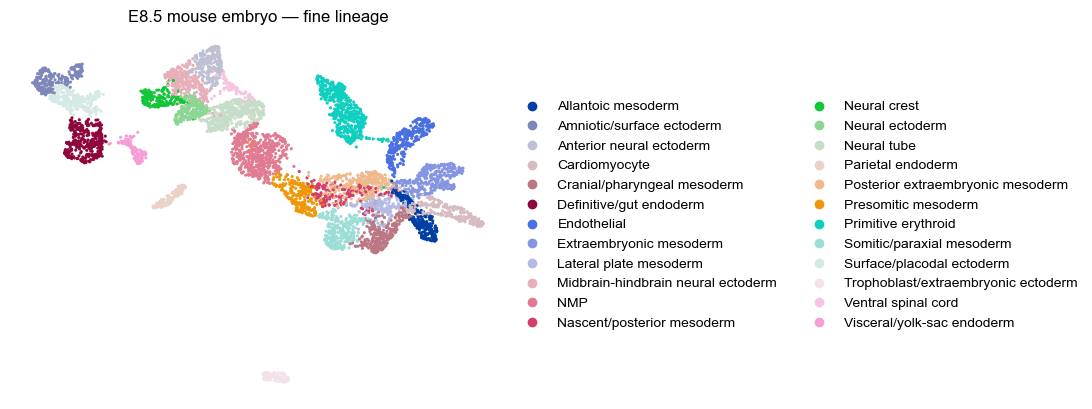

In [247]:
rna.obs[["leiden", "fine_lineage"]].drop_duplicates().sort_values("leiden")

sc.pl.umap(
    rna,
    color="fine_lineage",
    legend_loc="right margin",
    frameon=False,
    size=20,
    title="E8.5 mouse embryo — fine lineage"
)

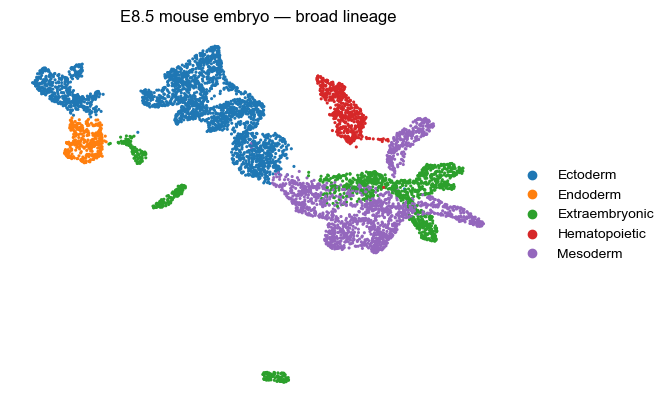

In [248]:
rna.obs[["leiden", "broad_lineage"]].drop_duplicates().sort_values("leiden")

sc.pl.umap(
    rna,
    color="broad_lineage",
    legend_loc="right margin",
    frameon=False,
    size=20,
    title="E8.5 mouse embryo — broad lineage"
)

### Dot Plot of Marker Genes by Broad Category

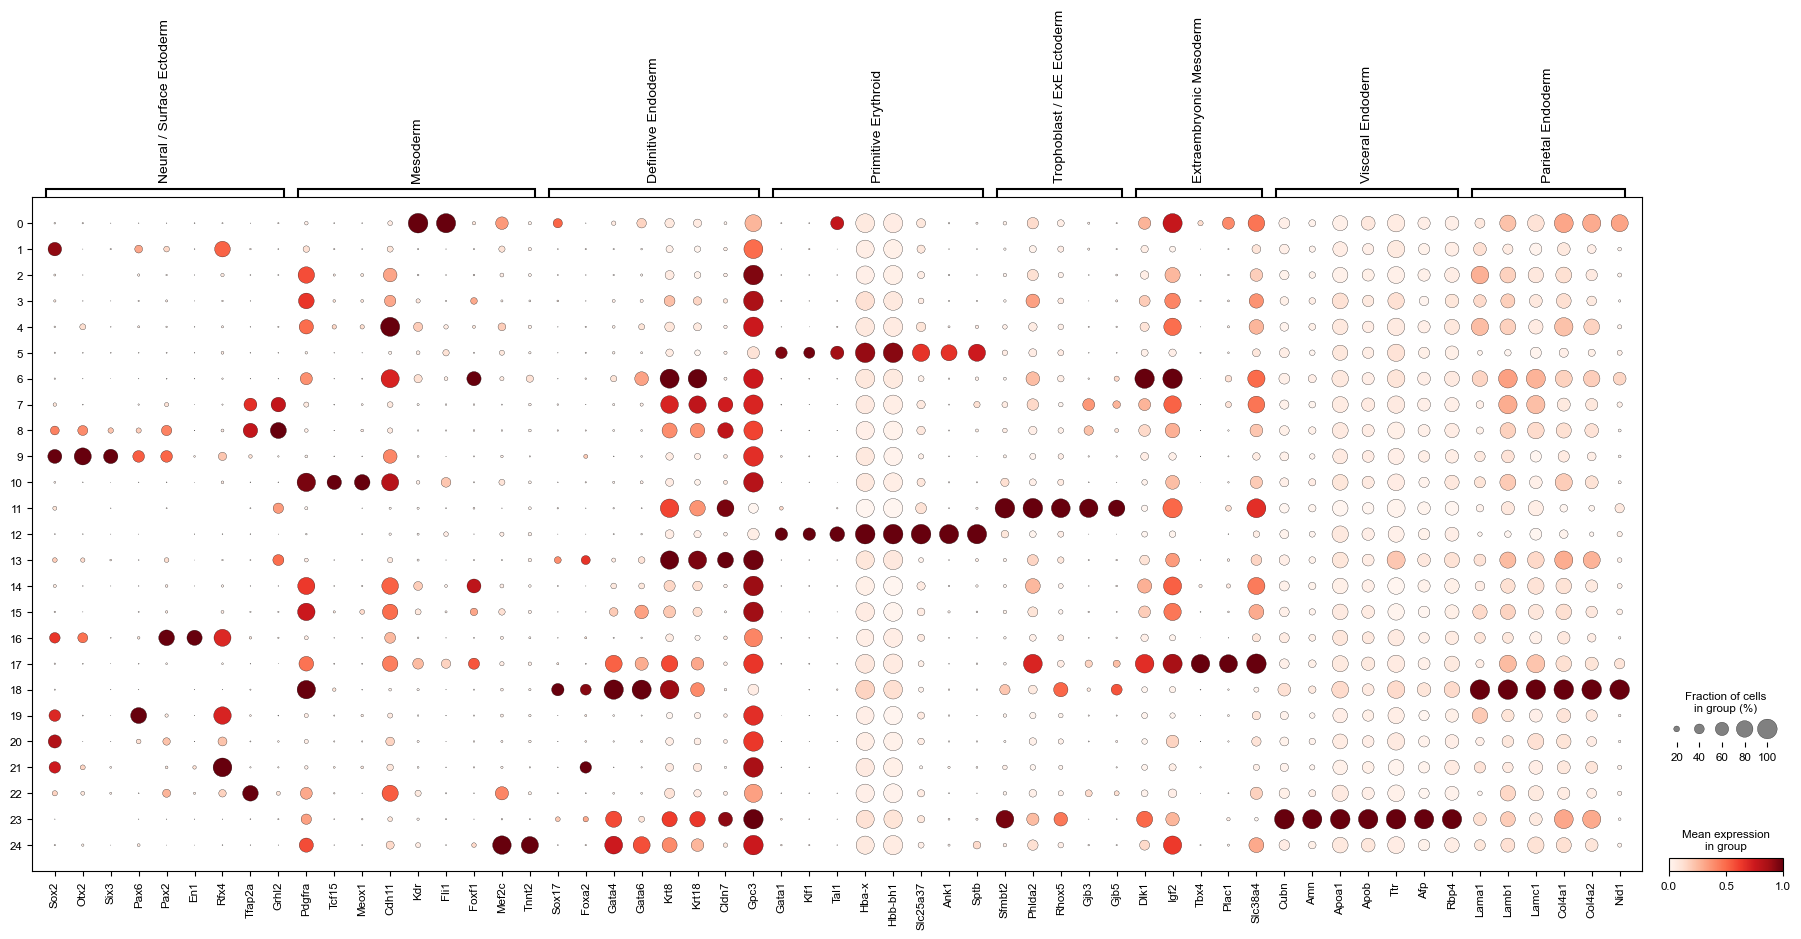

In [249]:
marker_groups = {
    "Neural / Surface Ectoderm": [
        "Sox2", "Otx2", "Six3", "Pax6",
        "Pax2", "En1", "Rfx4",
        "Tfap2a", "Grhl2",
    ],

    "Mesoderm": [
        "Pdgfra", "Tcf15", "Meox1",
        "Cdh11", "Kdr", "Fli1",
        "Foxf1", "Mef2c", "Tnnt2",
    ],

    "Definitive Endoderm": [
        "Sox17", "Foxa2", "Gata4", "Gata6",
        "Krt8", "Krt18", "Cldn7", "Gpc3",
    ],

    "Primitive Erythroid": [
        "Gata1", "Klf1", "Tal1",
        "Hba-x", "Hbb-bh1", "Slc25a37",
        "Ank1", "Sptb",
    ],

    "Trophoblast / ExE Ectoderm": [
        "Sfmbt2", "Phlda2", "Rhox5",
        "Gjb3", "Gjb5",
    ],

    "Extraembryonic Mesoderm": [
        "Dlk1", "Igf2", "Tbx4",
        "Plac1", "Slc38a4",
    ],

    "Visceral Endoderm": [
        "Cubn", "Amn", "Apoa1",
        "Apob", "Ttr", "Afp", "Rbp4",
    ],

    "Parietal Endoderm": [
        "Lama1", "Lamb1", "Lamc1",
        "Col4a1", "Col4a2", "Nid1",
    ],
}

# Drop unused Leiden categories
rna_de.obs["leiden"] = (
    rna_de.obs["leiden"]
    .cat.remove_unused_categories()
)

# Remove genes absent from the dataset
marker_groups = {
    group: [gene for gene in genes if gene in rna_de.var_names]
    for group, genes in marker_groups.items()
}

# Remove empty marker groups
marker_groups = {
    group: genes
    for group, genes in marker_groups.items()
    if len(genes) > 0
}

# Order clusters numerically
clusters_of_interest = [
    str(i)
    for i in range(25)
    if str(i) in rna_de.obs["leiden"].cat.categories
]

sc.pl.dotplot(
    rna_de,
    marker_groups,
    groupby="leiden",
    categories_order=clusters_of_interest,
    standard_scale="var",
    swap_axes=False,
    use_raw=False,
)

#### NMP Marker Genes

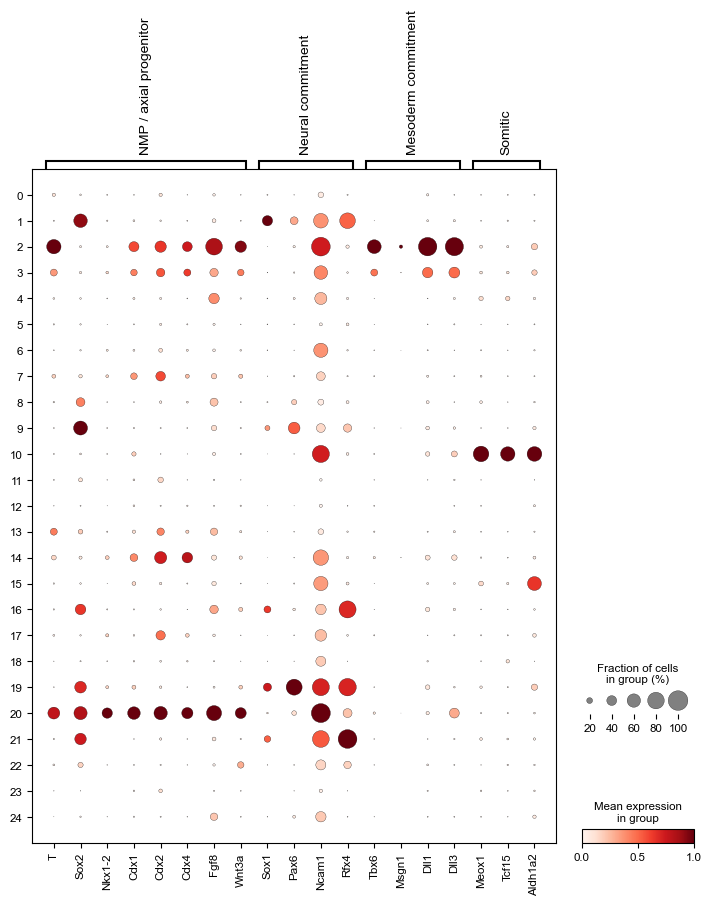

In [250]:
nmp_marker_groups = {
    "NMP / axial progenitor": [
        "T",
        "Sox2",
        "Nkx1-2",
        "Cdx1",
        "Cdx2",
        "Cdx4",
        "Fgf8",
        "Wnt3a",
    ],

    "Neural commitment": [
        "Sox1",
        "Pax6",
        "Ncam1",
        "Rfx4",
    ],

    "Mesoderm commitment": [
        "Tbx6",
        "Msgn1",
        "Dll1",
        "Dll3",
    ],

    "Somitic": [
        "Meox1",
        "Tcf15",
        "Aldh1a2",
    ],
}

# Drop unused Leiden categories
rna_de.obs["leiden"] = (
    rna_de.obs["leiden"]
    .cat.remove_unused_categories()
)

# Remove genes absent from the dataset
nmp_marker_groups = {
    group: [gene for gene in genes if gene in rna_de.var_names]
    for group, genes in nmp_marker_groups.items()
}

# Remove empty marker groups
nmp_marker_groups = {
    group: genes
    for group, genes in nmp_marker_groups.items()
    if len(genes) > 0
}

# Order clusters numerically
clusters_of_interest = [
    str(i)
    for i in range(25)
    if str(i) in rna_de.obs["leiden"].cat.categories
]

sc.pl.dotplot(
    rna_de,
    nmp_marker_groups,
    groupby="leiden",
    categories_order=clusters_of_interest,
    standard_scale="var",
    swap_axes=False,
    use_raw=False,
)

Cluster 20 has strong expression of NMP/posterior axial progenitor genes. Clusters 19 and 21 have strong expression of neural committment genes. From the previous marker genes, cluster 21 has strong evidence for ventralization due to Nkx6-1 and Hedgehog-response genes such as Ptch1. Cluster 19 is likely spinal cord / neural tube progenitor cells. 

### Plot of NMP differentiation

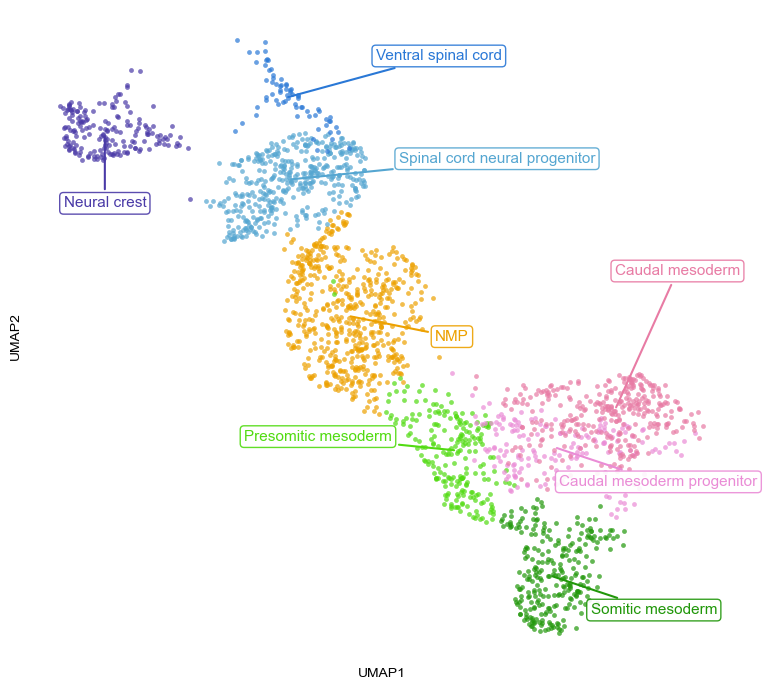

In [251]:
developmental_cluster_map = {
    "20": "NMP",
    "19": "Spinal cord neural progenitor",
    "21": "Ventral spinal cord",

    "2":  "Presomitic mesoderm",
    "10": "Somitic mesoderm",

    "3":  "Caudal mesoderm progenitor",
    "14": "Caudal mesoderm",

    "22": "Neural crest",
}

lineage_cols = {
    "NMP": "#eda100",
    "Spinal cord neural progenitor": "#55a6d1",
    "Ventral spinal cord": "#2a78d6",
    "Presomitic mesoderm": "#51db11",
    "Somitic mesoderm": "#21970a",
    "Caudal mesoderm progenitor": "#ea8cd6",
    "Caudal mesoderm": "#e87ba4",
    "Neural crest": "#4a3aa7",
}

# Clusters to include
clusters_to_plot = list(developmental_cluster_map.keys())

# Subset cells
rna_dev = rna_de[
    rna_de.obs["leiden"].astype(str).isin(clusters_to_plot)
].copy()

# Assign developmental lineage
rna_dev.obs["developmental_lineage"] = (
    rna_dev.obs["leiden"]
    .astype(str)
    .map(developmental_cluster_map)
)

# UMAP coordinates
umap = rna_dev.obsm["X_umap"]

fig, ax = plt.subplots(figsize=(8, 7))

# Plot each developmental lineage separately
for lineage, color in lineage_cols.items():

    mask = (
        rna_dev.obs["developmental_lineage"] == lineage
    ).to_numpy()

    ax.scatter(
        umap[mask, 0],
        umap[mask, 1],
        s=12,
        alpha=0.7,
        c=color,
        label=lineage.replace("_", " "),
        linewidths=0,
    )

# Add developmental lineage labels with lines pointing
# to the median UMAP position of each lineage
umap_label_offsets = {
    "NMP": (75, -15),
    "Spinal cord neural progenitor": (150, 15),
    "Ventral spinal cord": (110, 30),
    "Presomitic mesoderm": (-100, 10),
    "Somitic mesoderm": (75, -25),
    "Caudal mesoderm progenitor": (75, -25),
    "Caudal mesoderm": (45, 100),
    "Neural crest": (0, -50),
}

for lineage, color in lineage_cols.items():

    mask = (
        rna_dev.obs["developmental_lineage"] == lineage
    ).to_numpy()

    if not mask.any():
        continue

    # Median location of all cells belonging to this lineage
    x = np.median(umap[mask, 0])
    y = np.median(umap[mask, 1])

    offset = umap_label_offsets.get(lineage, (30, 30))

    ax.annotate(
        lineage.replace("_", " "),
        xy=(x, y),                  # point the line to this location
        xytext=offset,              # label offset in points
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=color,
        arrowprops=dict(
            arrowstyle="-",
            color=color,
            linewidth=1.5,
        ),
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor=color,
            alpha=0.9,
        ),
    )

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")

# ax.legend(
#     title="Developmental lineage",
#     bbox_to_anchor=(1.02, 1),
#     loc="upper left",
#     frameon=False,
# )

ax.set_xticks([])
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

### ForceAtlas2 NMP Differentiation Trajectory from kNN Connectivities

In [252]:
import networkx as nx

# subset data to developmental lineage clusters
clusters_to_plot = list(developmental_cluster_map.keys())

rna_dev = rna_de[
    rna_de.obs["leiden"].astype(str).isin(clusters_to_plot)
].copy()

rna_dev.obs["developmental_lineage"] = (
    rna_dev.obs["leiden"]
    .astype(str)
    .map(developmental_cluster_map)
)

# Get the kNN connectivities
connectivities = (
    rna_dev.obsp["connectivities"]
    .tocsr()
    .copy()
)

# Make symmetric and remove self-edges
connectivities = connectivities.maximum(connectivities.T)

connectivities.setdiag(0)
connectivities.eliminate_zeros()

# Convert to NetworkX
G = nx.from_scipy_sparse_array(
    connectivities,
    create_using=nx.Graph,
    edge_attribute="weight",
)


In [ ]:
# # Run ForceAtlas2
# pos = nx.forceatlas2_layout(
#     G,
#     max_iter=500,
#     scaling_ratio=2.0,
#     gravity=1.0,
#     weight="weight",
#     seed=42,
# )

# # Convert dictionary to an array matching rna_dev.obs order
# forceatlas = np.array([
#     pos[i]
#     for i in range(rna_dev.n_obs)
# ])

# # Save in AnnData
# rna_dev.obsm["X_forceatlas2"] = forceatlas

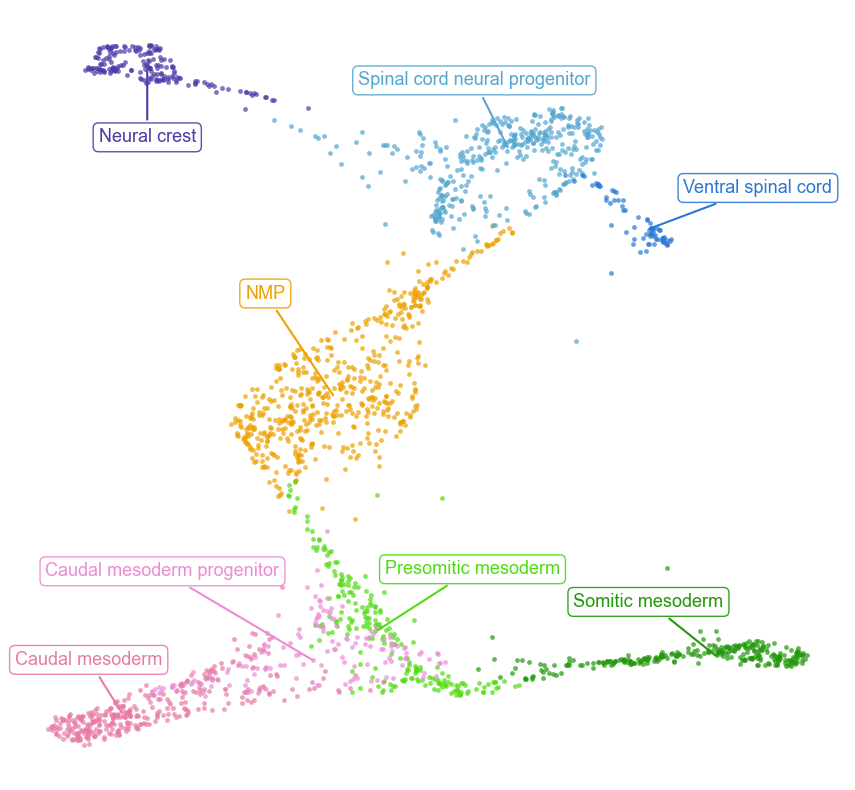

In [ ]:
# # -------------------------------------------------------
# # 5. Plot ForceAtlas2 layout
# # -------------------------------------------------------

# coords = rna_dev.obsm["X_forceatlas2"]

# fig, ax = plt.subplots(figsize=(9, 8))

# for lineage, color in lineage_cols.items():

#     mask = (
#         rna_dev.obs["developmental_lineage"] == lineage
#     ).to_numpy()

#     ax.scatter(
#         coords[mask, 0],
#         coords[mask, 1],
#         s=12,
#         alpha=0.7,
#         c=color,
#         linewidths=0,
#         label=lineage.replace("_", " "),
#     )

# # -------------------------------------------------------
# # 6. Add lineage labels
# # -------------------------------------------------------

# force_plot_label_offsets = {
#     "NMP": (-50, 75),
#     "Spinal cord neural progenitor": (-25, 50),
#     "Ventral spinal cord": (80, 30),
#     "Presomitic mesoderm": (70, 45),
#     "Somitic mesoderm": (-50, 40),
#     "Caudal mesoderm progenitor": (-110, 65),
#     "Caudal mesoderm": (-25, 40),
#     "Neural crest": (0, -50),
# }

# for lineage, color in lineage_cols.items():

#     mask = (
#         rna_dev.obs["developmental_lineage"] == lineage
#     ).to_numpy()

#     if not mask.any():
#         continue

#     # Median ForceAtlas2 position
#     x = np.median(coords[mask, 0])
#     y = np.median(coords[mask, 1])

#     ax.annotate(
#         lineage.replace("_", " "),
#         xy=(x, y),
#         xytext=force_plot_label_offsets.get(lineage, (30, 30)),
#         textcoords="offset points",
#         ha="center",
#         va="center",
#         fontsize=13,
#         fontweight="bold",
#         color=color,
#         arrowprops=dict(
#             arrowstyle="-",
#             color=color,
#             linewidth=1.5,
#         ),
#         bbox=dict(
#             boxstyle="round,pad=0.3",
#             facecolor="white",
#             edgecolor=color,
#             alpha=0.9,
            
#         ),
#     )


# ax.set_xlabel("")
# ax.set_ylabel("")

# ax.set_xticklabels([])
# ax.set_yticklabels([])

# ax.set_xticks([])
# ax.set_yticks([])

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["bottom"].set_visible(False)
# ax.spines["left"].set_visible(False)

# plt.tight_layout()
# plt.show()

In [255]:
import scipy.sparse as sp

genes = ["T", "Sox2", "Tbx6", "Msgn1"]

for gene in genes:
    if gene not in rna_dev.var_names:
        continue

    x = rna_dev[:, gene].X
    v = x.toarray().ravel() if sp.issparse(x) else np.asarray(x).ravel()

    df = pd.DataFrame({
        "expression": v,
        "lineage": rna_dev.obs["developmental_lineage"].values,
    })

    summary = (
        df.groupby("lineage", observed=True)
        .agg(
            mean_expression=("expression", "mean"),
            pct_expressing=("expression", lambda x: (x > 0).mean()),
        )
        .sort_values("mean_expression", ascending=False)
    )

    print(f"\n===== {gene} =====")
    print(summary.round(3).to_string())


===== T =====
                               mean_expression  pct_expressing
lineage                                                       
Presomitic mesoderm                      2.278           0.661
NMP                                      1.798           0.514
Caudal mesoderm progenitor               0.817           0.251
Caudal mesoderm                          0.357           0.153
Neural crest                             0.088           0.044
Ventral spinal cord                      0.082           0.029
Somitic mesoderm                         0.043           0.022
Spinal cord neural progenitor            0.040           0.015

===== Sox2 =====
                               mean_expression  pct_expressing
lineage                                                       
NMP                                      1.708           0.588
Ventral spinal cord                      1.530           0.493
Spinal cord neural progenitor            1.428           0.502
Neural crest          

These lineage-specific gene expression patterns line up with the original paper's results

In [256]:
nmp_metacells = rna_dev.obs_names.to_list()
print(nmp_metacells)

['AAACATGCAATGCCCG-1', 'AAACATGCACTATGGC-1', 'AAACCAACATTGTGTG-1', 'AAACCGCGTTGAGGTC-1', 'AAAGCAAGTGCCGCAA-1', 'AAAGCAAGTTAAGCTG-1', 'AAAGCACCAACCTAAT-1', 'AAAGCACCAATGCGCT-1', 'AAAGCACCACTAAGTT-1', 'AAAGCCCGTTCCTGAT-1', 'AAAGCCGCAAGCTAAA-1', 'AAAGCCGCATCCGTAA-1', 'AAAGCGGGTCGTTATC-1', 'AAAGGAGCAAATACCT-1', 'AAAGGAGCATAGCAGG-1', 'AAAGGAGCATTGACAT-1', 'AAAGGTTAGGAACGGT-1', 'AAAGGTTAGTCGCTAG-1', 'AAATCCGGTAGGATTT-1', 'AAATCCGGTCAATGTG-1', 'AAATCCGGTGGGTGAA-1', 'AAATCCGGTGGTGAGA-1', 'AACAAAGGTGAGCAAG-1', 'AACAAAGGTTGGATCA-1', 'AACAAGCCATGAATAG-1', 'AACAGATAGGAGGTTA-1', 'AACCGCTCACTGACCG-1', 'AACCGCTCATAGACCC-1', 'AACCGCTCATCAGTAT-1', 'AACCGCTCATCTTGAG-1', 'AACCGGCTCCTTGTTG-1', 'AACCGGCTCTAAGGTC-1', 'AACCGGCTCTTTAGGA-1', 'AACCTAATCCTGTTCA-1', 'AACCTAATCTAAATCG-1', 'AACCTAATCTCAATTC-1', 'AACGCCCAGCAGCTAT-1', 'AACGCTAGTACCTTAC-1', 'AACGCTAGTGATTACG-1', 'AACGCTAGTTGCGGAT-1', 'AACTAGCTCGAGGTGG-1', 'AACTAGCTCGTTAACA-1', 'AACTAGCTCTTGATGA-1', 'AACTAGTGTAGACAAA-1', 'AACTCACAGTGAACGA-1', 'AACTTAGT

## Hepatocyte Model Predictions for E8.5

A TETHER model was trained using data from `hepatocytes_1`. We will use it to make TF-TG predictions using the cells in the NMP trajectory. First, we will generate a file containing the cell barcodes for the NMP trajectory metacells.

In [257]:
# metacell_file = output_dir / "E8.5_rep1_NMP_metacells.txt"

# with open(metacell_file, "w") as file:
#     for metacell in nmp_metacells:
#         file.write(metacell)
#         file.write(",")

Next, we will generate a GRN using the NMP metacells using the `hepatocytes_1` trained model. 

`sbatch run_generate_hepatocyte_vs_nmp_grn.sh`

Once that finishes running, we can load in the predictions:

In [258]:
prediction_df = pd.read_csv(output_dir / "hepatocyte_model_vs_E8.5_rep1_NMP_metacell_GRN.csv", index_col=0)
prediction_df

,Source,Target,Score
0,ADNP,0610006L08RIK,0.158540
1,ADNP,0610009E02RIK,0.374138
2,ADNP,0610009L18RIK,0.267259
3,ADNP,0610012D04RIK,0.198981
4,ADNP,0610025J13RIK,0.207875
...,...,...,...
7464365,ZKSCAN1,ZYG11A,0.161708
7464366,ZKSCAN1,ZYG11B,0.440862
7464367,ZKSCAN1,ZYX,0.387765
7464368,ZKSCAN1,ZZEF1,0.309777


Next, we will filter the scores to only show the top 25 targets of each TF

In [259]:
top_tf_prediction_df = prediction_df.copy()
top_tf_prediction_df = (top_tf_prediction_df
                        .sort_values("Score", ascending=False)
                        .groupby("Source", sort=False)
                        .head(25)
                        .reset_index(drop=True)
                        )
top_tf_prediction_df

,Source,Target,Score
0,KLF4,PRTG,0.999781
1,KLF4,RERE,0.999717
2,KLF5,COL18A1,0.999610
3,KLF5,PLEKHA5,0.999604
4,KLF5,GPC3,0.999572
...,...,...,...
10745,E4F1,SPARC,0.082875
10746,E4F1,AIRN,0.081860
10747,E4F1,IFRD2,0.081384
10748,E4F1,HOXB8,0.080881


In [260]:
print(f"Number of TFs: {top_tf_prediction_df['Source'].nunique()}")
print(f"Number of predicted interactions: {len(top_tf_prediction_df)}")

Number of TFs: 430
Number of predicted interactions: 10750


In [261]:
num_interactions_per_target = (
top_tf_prediction_df.groupby("Target")
    .size()
    .reset_index(name="num_interactions")
    .sort_values("num_interactions", ascending=False)
)
num_interactions_per_target

,Target,num_interactions
1662,PBX3,139
1767,PODXL,130
1856,PTPN13,124
480,COL18A1,90
1412,MEIS2,76
...,...,...
44,4930596I21RIK,1
45,4930599N23RIK,1
35,4930453N24RIK,1
36,4930473H19RIK,1


Some of the targets are hubs for TF-TG interactions. We should take this into account to weight the TF-TG edge score by how specific the interaction is for the TF. We can use a simple IDF-like metric where the specificity is inversely related to the proportion of TFs targeting the TG.

$$\text{Specificity(TG)} = log\left(\frac{1 + N_{\text{TF}}}{1 + N_{\text{TFs predicting TG}}}\right)$$

> Note: The +1 added to the numerator and demoninator makes it so that the specificity can never become negative (previously possible if all TFs targeted a TG)

In [262]:
top_tf_prediction_adj_df = top_tf_prediction_df.copy()

num_tfs = top_tf_prediction_adj_df["Source"].nunique()

top_tf_prediction_adj_df["num_tfs_targeting"] = (
    top_tf_prediction_adj_df
    .groupby("Target")["Source"]
    .transform("nunique")
)

top_tf_prediction_adj_df["tf_specificity"] = np.log(
    (num_tfs + 1) / (top_tf_prediction_adj_df["num_tfs_targeting"] + 1)
)

top_tf_prediction_adj_df["tf_specificity"] = top_tf_prediction_adj_df["tf_specificity"] / top_tf_prediction_adj_df["tf_specificity"].max()

top_tf_prediction_adj_df["Score_adjusted"] = (
    top_tf_prediction_adj_df["tf_specificity"] * top_tf_prediction_adj_df["Score"]
)

top_tf_prediction_adj_df = (
    top_tf_prediction_adj_df
    .sort_values("Score", ascending=False)
    .reset_index(drop=True)
)

top_tf_prediction_adj_df

,Source,Target,Score,num_tfs_targeting,tf_specificity,Score_adjusted
0,KLF4,PRTG,0.999781,5,0.795529,0.795355
1,KLF4,RERE,0.999717,13,0.637833,0.637652
2,KLF5,COL18A1,0.999610,90,0.289458,0.289346
3,KLF5,PLEKHA5,0.999604,10,0.682717,0.682447
4,KLF5,GPC3,0.999572,22,0.545437,0.545204
...,...,...,...,...,...,...
10745,E4F1,SPARC,0.082875,9,0.700456,0.058050
10746,E4F1,AIRN,0.081860,40,0.437847,0.035842
10747,E4F1,IFRD2,0.081384,1,1.000000,0.081384
10748,E4F1,HOXB8,0.080881,1,1.000000,0.080881


In [263]:
top_tf_prediction_adj_df.describe()

,Score,num_tfs_targeting,tf_specificity,Score_adjusted
count,10750.000000,10750.000000,10750.000000,10750.000000
mean,0.725691,21.343628,0.682338,0.484810
std,0.210971,29.506709,0.220901,0.203142
min,0.079331,1.000000,0.209282,0.017401
25%,0.613807,3.000000,0.522619,0.329219
50%,0.752045,9.000000,0.700456,0.475084
75%,0.905049,25.000000,0.870993,0.625335
max,0.999781,139.000000,1.000000,0.998505


Next, we will filter the network to remove low-scoring TF-TG interactions

In [264]:
top_n_interactions = len(top_tf_prediction_adj_df)
max_edges_per_tf = 10

min_score_threshold = top_tf_prediction_adj_df["Score"].quantile(0.75)
min_specificity_threshold = top_tf_prediction_adj_df["tf_specificity"].quantile(0.75)
min_num_targets_per_tf = 5


filtered_df = top_tf_prediction_adj_df[
    (top_tf_prediction_adj_df["Score"] >= min_score_threshold)
    & (
        top_tf_prediction_adj_df["tf_specificity"]
        >= min_specificity_threshold
    )
].copy()


# Keep strongest specificity-adjusted edges per TF
filtered_df = (
    filtered_df
    .sort_values(
        ["Source", "Score_adjusted"],
        ascending=[True, False],
    )
    .groupby("Source", group_keys=False)
    .head(max_edges_per_tf)
)


# Global ranking for plotting
filtered_top_tf_prediction_adj_df = (
    filtered_df
    .sort_values(
        "Score_adjusted",
        ascending=False,
    )
    .head(top_n_interactions)
    .reset_index(drop=True)
)

# Number of qualifying targets AFTER filtering
filtered_top_tf_prediction_adj_df["num_targets"] = (
    filtered_top_tf_prediction_adj_df
    .groupby("Source")["Target"]
    .transform("nunique")
)


# Require a regulatory program of at least N targets
filtered_top_tf_prediction_adj_df = filtered_top_tf_prediction_adj_df[
    filtered_top_tf_prediction_adj_df["num_targets"]
    >= min_num_targets_per_tf
].copy()


We can plot the filtered top prediction network to see how it looks

Filtering Settings:
  Minimum number of targets per TF: 5
  Minimum score threshold: 0.9050485525
  Minimum specificity threshold: 0.8709934443541675
Number of communities: 26
[19, 6, 16, 11, 16, 17, 17, 20, 6, 11, 11, 6, 11, 11, 6, 9, 19, 12, 8, 17, 22, 6, 11, 22, 16, 21]


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/networkx/drawing/layout.py:1442: RuntimeWarning: invalid value encountered in divide
  attraction = -np.log(1 + distance) / distance


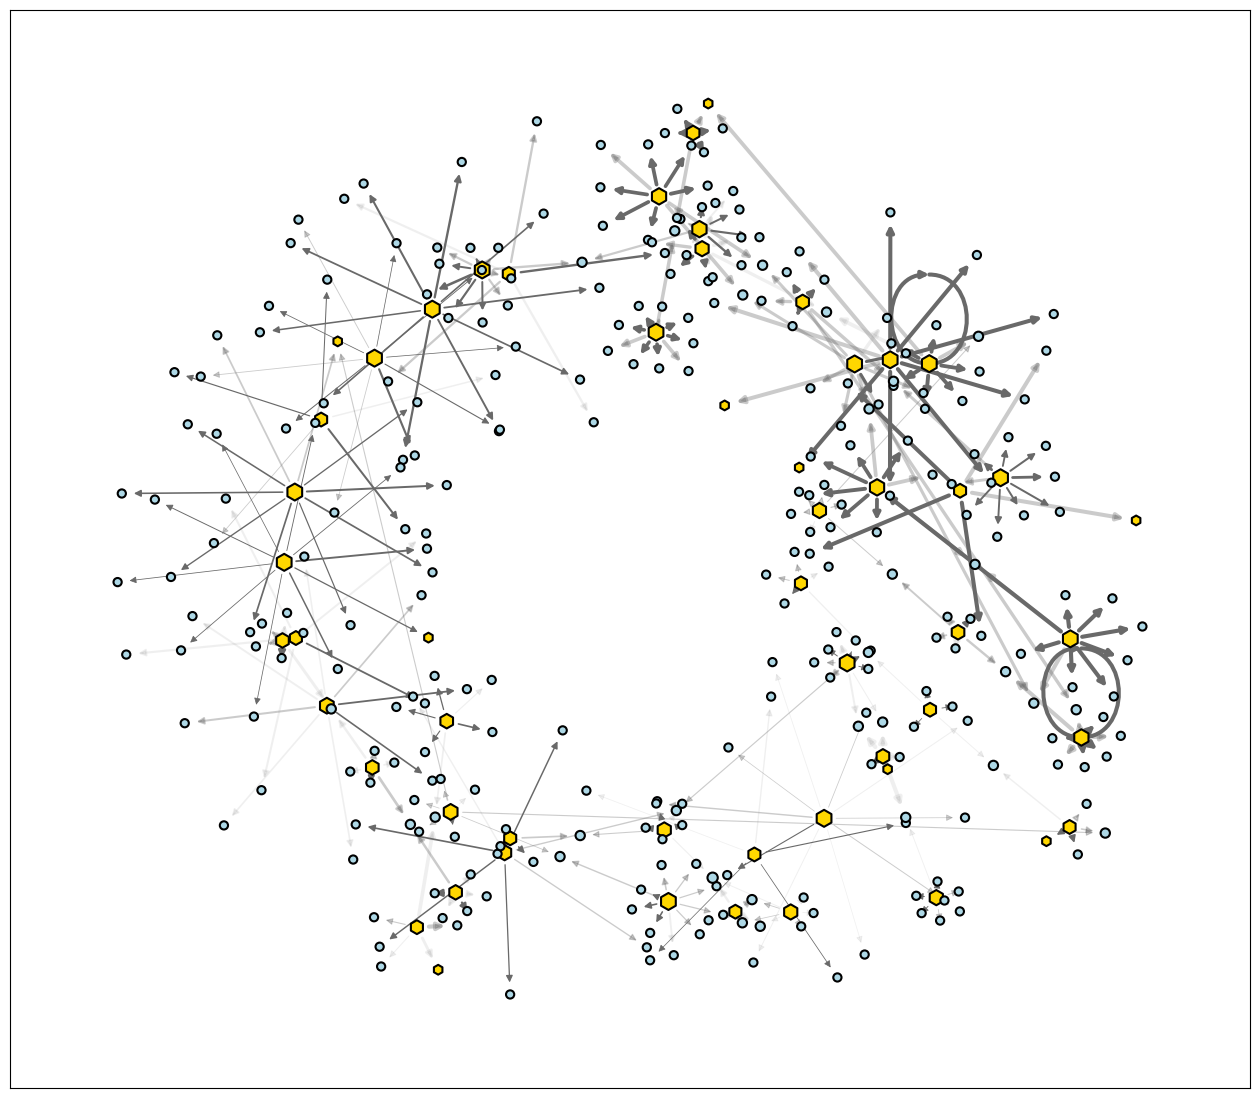

In [265]:
import networkx as nx

G = nx.from_pandas_edgelist(
    filtered_top_tf_prediction_adj_df,
    source="Source",
    target="Target",
    edge_attr=["Score", "Score_adjusted", "tf_specificity"],
    create_using=nx.DiGraph(),
)


# Group by community using the Louvain method
G_comm = G.to_undirected().copy()
G_comm.remove_edges_from(nx.selfloop_edges(G_comm))

communities = nx.community.louvain_communities(
    G_comm,
    weight="Score_adjusted",
    resolution=1.0,
    seed=42,
)

print(f"Filtering Settings:")
print(f"  Minimum number of targets per TF: {min_num_targets_per_tf}")
print(f"  Minimum score threshold: {min_score_threshold}")
print(f"  Minimum specificity threshold: {min_specificity_threshold}")

print(f"Number of communities: {len(communities)}")
print([len(c) for c in communities])

n_communities = len(communities)

community_centers = nx.circular_layout(
    nx.path_graph(n_communities),
    scale=10,
)

# Lay out each community separately
pos = {}

for i, community in enumerate(communities):

    subgraph = G.subgraph(community).to_undirected()

    local_pos = nx.forceatlas2_layout(
        subgraph,
        max_iter=500,
        scaling_ratio=10.0,
        gravity=0.5,
        weight="Score_adjusted",
        linlog=True,
        seed=42,
    )

    # Normalize local community size
    local_pos = nx.rescale_layout_dict(
        local_pos,
        scale=5.0,
    )

    center = community_centers[i]

    for node, xy in local_pos.items():
        pos[node] = xy + center

plt.figure(figsize=(16, 14))
nodes = list(G.nodes())

tf_list = top_tf_prediction_adj_df["Source"].unique().tolist()
tg_list = top_tf_prediction_adj_df["Target"].unique().tolist()
tg_list = [x for x in tg_list if x not in tf_list]

tf_nodes = [n for n in nodes if n in tf_list]
tg_nodes = [n for n in nodes if n in tg_list]

tf_outgoing_edges = {node: list(G.out_edges(node)) for node in tf_nodes}
tg_incoming_edges = {node: list(G.in_edges(node)) for node in tg_nodes}

# Set the edge size and opacity based on the Score and tf_specificity attributes
scores = np.array([
    G[u][v]["Score"]
    for u, v in G.edges()
])

specificities = np.array([
    G[u][v]["tf_specificity"]
    for u, v in G.edges()
])

score_min, score_max = scores.min(), scores.max()
spec_min, spec_max = specificities.min(), specificities.max()

score_scaled = (
    (scores - score_min)
    / max(score_max - score_min, 1e-12)
)

spec_scaled = (
    (specificities - spec_min)
    / max(spec_max - spec_min, 1e-12)
)

edge_size = np.clip(
    0.5 + 2.5 * score_scaled**1.5,
    0.0,
    5.0,
)

edge_opacity = np.clip(
    0.10 + 0.90 * spec_scaled**1.5,
    0.10,
    1.0,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=tf_nodes,
    node_color="gold",
    node_size=[50 + (10 * len(edges)) for edges in tf_outgoing_edges.values()],
    node_shape="h",
    edgecolors="black",
    linewidths=1.5,
)

nx.draw_networkx_nodes(
    G,
    pos,
    nodelist=tg_nodes,
    node_color="lightblue",
    node_size=[25 + (10 * len(edges)) for edges in tg_incoming_edges.values()],
    node_shape="o",
    edgecolors="black",
    linewidths=1.5,
)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=G.edges(),
    width=edge_size,
    edge_color="dimgray",
    alpha=edge_opacity,
    arrowsize=10,
    arrowstyle="-|>",
)

plt.show()


In [266]:
# Add community IDs to nodes
for community_id, community in enumerate(communities):
    for node in community:
        G.nodes[node]["community"] = int(community_id)

# Add plotted x/y coordinates
for node, xy in pos.items():
    G.nodes[node]["x"] = float(xy[0])
    G.nodes[node]["y"] = float(xy[1])

# Add node type
for node in tf_nodes:
    G.nodes[node]["node_type"] = "TF"

for node in tg_nodes:
    G.nodes[node]["node_type"] = "TG"

# Export
output_graphml_path = output_dir / "specificity_adjusted_regulatory_network.graphml"

nx.write_graphml(
    G,
    output_graphml_path,
)

print(f"Saved GraphML to: {output_graphml_path}")

Saved GraphML to: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/TETHER/mouse_development_testing/specificity_adjusted_regulatory_network.graphml


## NMP Differentiation-Associated Genes

[Koch, et. al. 2017](https://www.sciencedirect.com/science/article/pii/S153458071730597X?via%3Dihub) performed ChIP-seq for Brachyury and Sox2, mapping the binding sites to their nearest neighbors. They looked at which genes were differentially expressed between 5 clusters from their single-cell RNA-seq data.

They provide their ChIP-seq results with labeled groups under their supplemental information [Table S2](https://ars.els-cdn.com/content/image/1-s2.0-S153458071730597X-mmc3.xlsx)

In [267]:
chip_dir = output_dir / "ChIP-seq"
sox2_chip_df = pd.read_csv(chip_dir / "Sox2_chipseq_genes.tsv", sep='\t')
t_and_sox2_chip_df = pd.read_csv(chip_dir / "T_and_Sox2_chipseq_genes.tsv", sep='\t')
t_chip_df = pd.read_csv(chip_dir / "T_chipseq_genes.tsv", sep='\t')

# Duplicate the t_and_sox2_chip_df for T and Sox2 separately
t_chip_from_t_and_sox2_df = t_and_sox2_chip_df.copy()
t_chip_from_t_and_sox2_df["Source"] = "T"

sox2_chip_from_t_and_sox2_df = t_and_sox2_chip_df.copy()
sox2_chip_from_t_and_sox2_df["Source"] = "Sox2"

# Add specifier columns, then merge
sox2_chip_df["Source"] = "Sox2"
t_chip_df["Source"] = "T"

full_chip_df = pd.concat([
    sox2_chip_df,
    t_chip_df,
    sox2_chip_from_t_and_sox2_df,
    t_chip_from_t_and_sox2_df,
], ignore_index=True)

full_chip_df = full_chip_df.rename(columns={"Gene": "Target"})[["Source", "Target", "Group_Name"]]

full_chip_df["Source"] = full_chip_df["Source"].str.upper()
full_chip_df["Target"] = full_chip_df["Target"].str.upper()

full_chip_df.to_csv(chip_dir / "NMP_T_and_Sox2_chipseq_data.csv", index=False)

full_chip_df

,Source,Target,Group_Name
0,SOX2,1190005I06RIK,Nascent mesoderm
1,SOX2,1300002E11RIK,Late neural
2,SOX2,2810429I04RIK,Late neural
3,SOX2,ABCA2,Early neural
4,SOX2,ACOT1,Late neural
...,...,...,...
1574,T,ZFP169,Late neural
1575,T,ZFP677,Nascent mesoderm
1576,T,ZFPM1,Lateral and intermediate mesoderm
1577,T,ZHX2,Early mesoderm


We can double-check that the 

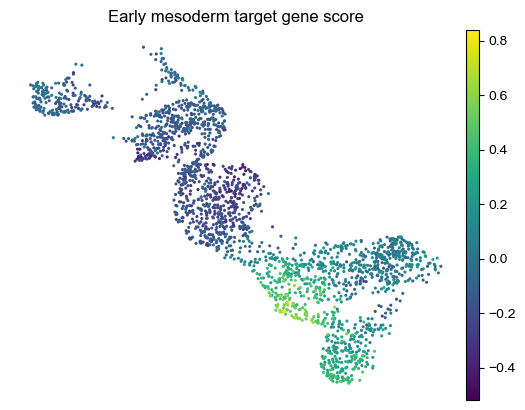

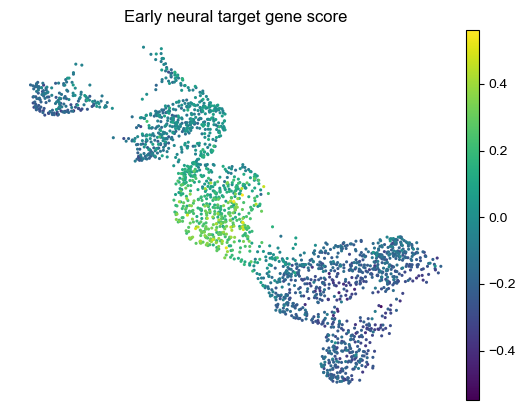

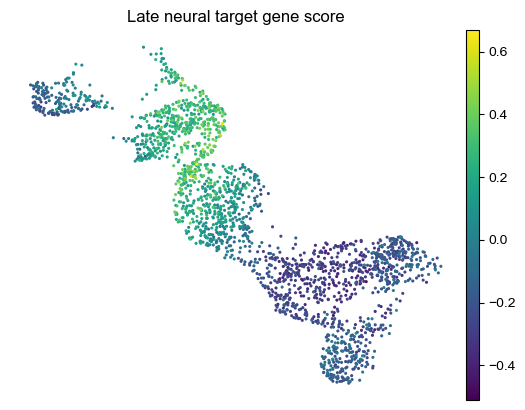

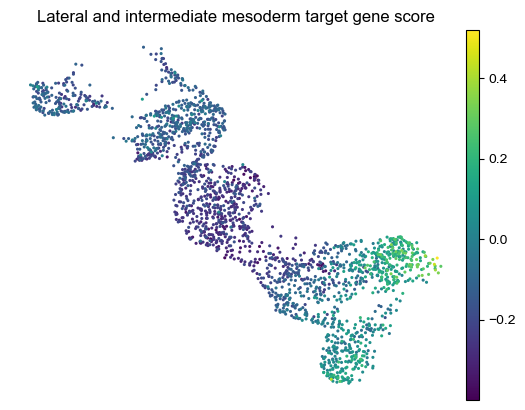

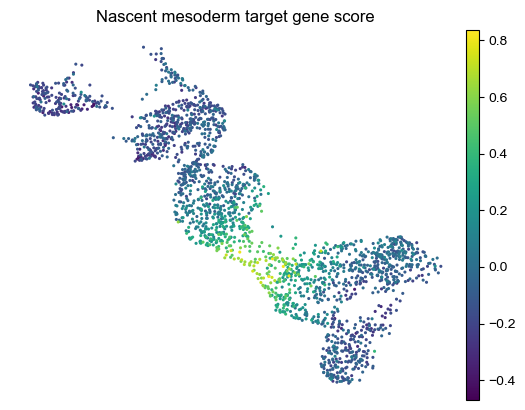

In [290]:
for lineage, results in full_chip_df.groupby("Group_Name"):

    target_genes = [gene.capitalize() for gene in results['Target'].unique() if gene.capitalize() in rna_dev.var_names]

    if len(target_genes) == 0:
        print(f"{lineage}: no genes found in rna_dev.var_names")
        continue

    score_name = (
        lineage.replace(" ", "_").replace("-", "_")
        + "_target_score"
    )

    sc.tl.score_genes(
        rna_dev,
        gene_list=target_genes,
        score_name=score_name,
        use_raw=False,
    )

    sc.pl.umap(
        rna_dev,
        color=score_name,
        title=f"{lineage} target gene score",
        cmap="viridis",
        frameon=False,
        size=20,
    )

We can use this ChIP-seq data to check the GRN. The GRN should contain the ChIP-seq edges in the top percentile of scores. We can use a one-sided Wilcoxon signed-rank test to determine if the GRN ranks ChIP-seq target genes significantly higher than non-ChIP-seq target genes.

In [273]:
from scipy.stats import percentileofscore, wilcoxon

def calculate_chipseq_percentiles(prediction_df, full_chip_df):
    """
    Calculate the percentile and rank of curated ChIP-seq edges
    within the predicted regulatory network scores.

    Parameters:
    - prediction_df: DataFrame containing predicted regulatory interactions with scores.
    - full_chip_df: DataFrame containing curated ChIP-seq edges.

    Returns:
    - curated_results_df: DataFrame with Source, Target, Score, percentile, and rank.
    """
    
    # Group once per TF so we're not re-filtering the 7.4M-row prediction_df
    # for every curated edge
    tf_target_scores = {
        tf: prediction_df.loc[prediction_df["Source"] == tf, ["Target", "Score"]]
        for tf in full_chip_df["Source"].unique()
    }

    results = []
    for _, edge in full_chip_df.iterrows():
        if edge["Source"] not in tf_target_scores:
            continue
        
        tf_scores = tf_target_scores[edge["Source"]]
        
                
        if edge["Target"] not in tf_scores["Target"].values:
            continue
        
        score = tf_scores.loc[tf_scores["Target"] == edge["Target"], "Score"].iloc[0]
        pct = percentileofscore(tf_scores["Score"], score, kind="mean")
        rank = int((tf_scores["Score"] > score).sum() + 1)

        results.append({
            "Source": edge["Source"],
            "Target": edge["Target"],
            "Score": score,
            "percentile": pct,
            "rank": rank,
        })

    curated_results_df = (
        pd.DataFrame(results)
        .sort_values("percentile", ascending=False)
        .reset_index(drop=True)
    )
    
    print(f"TFs: {curated_results_df['Source'].nunique()}")
    print(f"TGs: {curated_results_df['Target'].nunique()}")
    print(f"Curated edges found in predictions: {len(curated_results_df)}")

    curated_results_df["n_candidate_targets"] = curated_results_df.groupby("Source")["Target"].transform("count")
    
    median_percentile = curated_results_df["percentile"].median()
    random_percentile = np.random.uniform(0, 100, size=len(curated_results_df)).mean()

    print(f"Median percentile of curated edges: {median_percentile:.2f} (random: {random_percentile:.2f})")

    # One-sided Wilcoxon signed-rank test against the null that curated edges
    # are just random targets (expected median percentile = 50)
    stat, pval = wilcoxon(
        curated_results_df["percentile"] - random_percentile,
        alternative="greater",
    )

    print(f"  Wilcoxon signed-rank W = {stat:.1f}, one-sided p = {pval:.4g}")
    
    return curated_results_df

curated_results_df = calculate_chipseq_percentiles(
    prediction_df=prediction_df,
    full_chip_df=full_chip_df,
)

TFs: 2
TGs: 775
Curated edges found in predictions: 1235
Median percentile of curated edges: 76.00 (random: 49.78)
  Wilcoxon signed-rank W = 601015.0, one-sided p = 7.037e-69


We can also see if the predictions would be different depending on the cell lineage

In [274]:
lineage_results = {}
for lineage in full_chip_df["Group_Name"].unique():
    print(f"\n===== {lineage} =====")
    lineage_df = full_chip_df[full_chip_df["Group_Name"] == lineage]
    
    lineage_results_df = calculate_chipseq_percentiles(
        prediction_df=prediction_df,
        full_chip_df=lineage_df,
    )
    
    median_percentile = lineage_results_df["percentile"].median()
    random_percentile = np.random.uniform(0, 100, size=len(lineage_results_df)).mean()
    
    lineage_results[lineage] = {
        "median_percentile": median_percentile,
        "random_percentile": random_percentile,
        "target_genes": lineage_df["Target"].unique().tolist(),
    }


===== Nascent mesoderm =====
TFs: 2
TGs: 82
Curated edges found in predictions: 133
Median percentile of curated edges: 66.14 (random: 45.39)
  Wilcoxon signed-rank W = 6874.0, one-sided p = 2.794e-08

===== Late neural =====
TFs: 2
TGs: 188
Curated edges found in predictions: 299
Median percentile of curated edges: 78.38 (random: 50.92)
  Wilcoxon signed-rank W = 37153.0, one-sided p = 3.664e-23

===== Early neural =====
TFs: 2
TGs: 156
Curated edges found in predictions: 251
Median percentile of curated edges: 74.23 (random: 48.29)
  Wilcoxon signed-rank W = 25272.0, one-sided p = 1.057e-16

===== Lateral and intermediate mesoderm =====
TFs: 2
TGs: 203
Curated edges found in predictions: 311
Median percentile of curated edges: 76.43 (random: 50.45)
  Wilcoxon signed-rank W = 36518.0, one-sided p = 5.596e-15

===== Early mesoderm =====
TFs: 2
TGs: 146
Curated edges found in predictions: 241
Median percentile of curated edges: 76.06 (random: 53.45)
  Wilcoxon signed-rank W = 21671.0, 

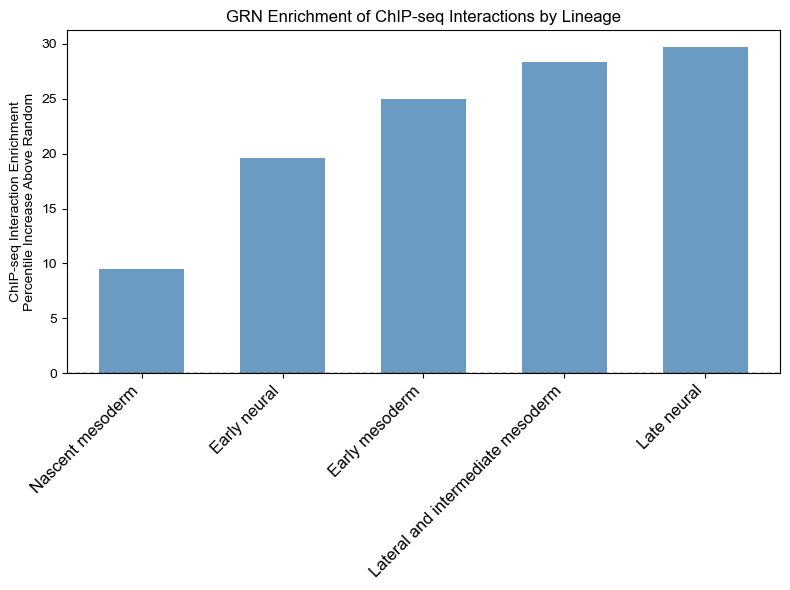

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate percentile increase above random
lineage_percentile_diff = {
    lineage: (
        results["median_percentile"]
        - results["random_percentile"]
    )
    for lineage, results in lineage_results.items()
}

# Sort from highest to lowest
lineage_percentile_diff = dict(
    sorted(
        lineage_percentile_diff.items(),
        key=lambda x: x[1],
        reverse=False,
    )
)

lineages = list(lineage_percentile_diff.keys())
median_percentile_above_random = list(
    lineage_percentile_diff.values()
)

x = np.arange(len(lineages))
width = 0.6

ax.bar(
    x,
    median_percentile_above_random,
    width=width,
    color="steelblue",
    alpha=0.8,
)

ax.axhline(
    0,
    color="black",
    linewidth=1,
    linestyle="--",
)

ax.set_xticks(x)
ax.set_xticklabels(
    lineages,
    rotation=45,
    ha="right",
    fontsize=12
)

ax.set_ylabel("ChIP-seq Interaction Enrichment\nPercentile Increase Above Random")

plt.title("GRN Enrichment of ChIP-seq Interactions by Lineage")
plt.tight_layout()
plt.show()

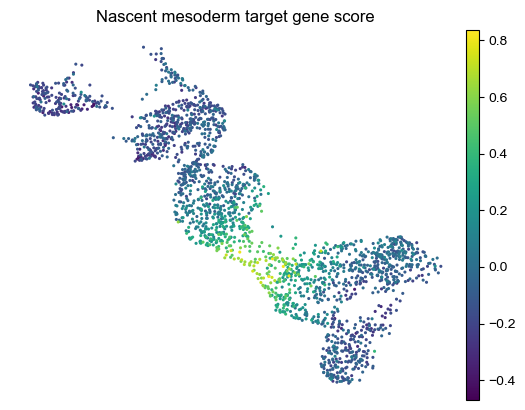

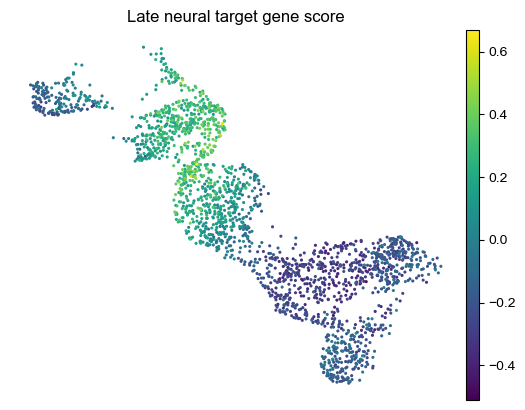

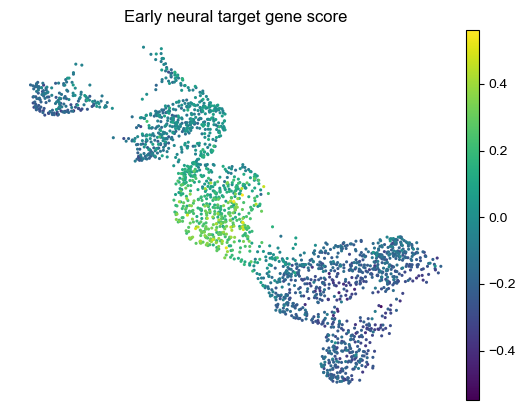

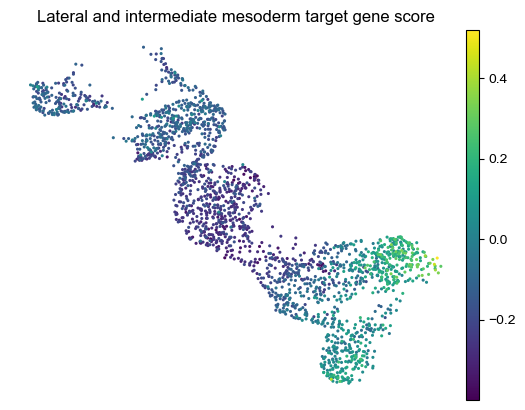

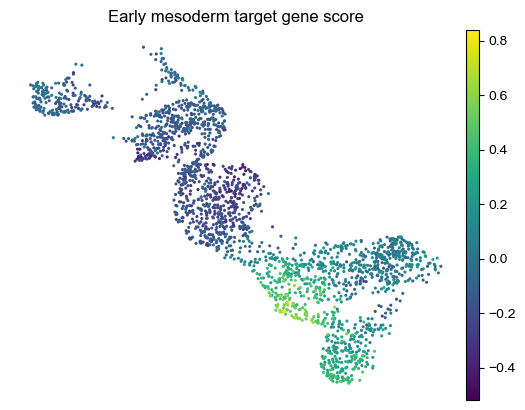

In [280]:
ncols = 4
for lineage, results in lineage_results.items():

    target_genes = [gene.capitalize() for gene in results["target_genes"] if gene.capitalize() in rna_dev.var_names]

    if len(target_genes) == 0:
        print(f"{lineage}: no genes found in rna_dev.var_names")
        continue

    score_name = (
        lineage.replace(" ", "_").replace("-", "_")
        + "_target_score"
    )

    sc.tl.score_genes(
        rna_dev,
        gene_list=target_genes,
        score_name=score_name,
        use_raw=False,
    )

    sc.pl.umap(
        rna_dev,
        color=score_name,
        title=f"{lineage} target gene score",
        cmap="viridis",
        frameon=False,
        size=20,
    )

In all cell lineages, the GRN scores TF-TG pairs that are in the ChIP-seq data significantly higher than TF-TG pairs that are NOT in the ChIP-seq data. The nascent mesoderm (Group I from the paper) had the lowest median percentile of curated edges. This group contains genes expressed in T^{+}/Soc2^{+} (NMP) cells, but which are downregulated in Sox2^{+} (neural) and T^{+} (mesoderm) cells. The lineages with the highest median percentile of curated edges were the late neural and the lateral and intermediate mesoderm lineages. These results show that our method assigns significantly higher scores to real TF-TG regulatory relationships compared to random, with improved performance in highly-differentiated cell lineages compared to early intermediate cell lineages.

We can also test if this 

## Testing for Known NMP TF→TG Relationships

The network above is descriptive — it doesn't tell us whether the `hepatocytes_1`-trained model is actually recovering *real* NMP regulatory biology, or just generic high-confidence edges. To test that, we compare the model's predictions against a small literature-curated set of TF→target relationships known to operate in NMPs / the neuro-mesodermal bifurcation (T/Brachyury, Sox2, Cdx2, Pax6 axis).

Curated edges are restricted to TFs that are actually in the model's TF vocabulary (`prediction_df["Source"]`) — only `T`, `SOX2`, `CDX2`, and `PAX6` from the core NMP program have TF-DNA embeddings; `TBX6`, `CDX1/4`, `NKX1-2`, `MSGN1`, `DLL1/3`, `WNT3A`, `FGF8` are only scorable as *targets*, not as regulators, so any edge with one of those as the TF can't be tested this way.

Each edge is tagged as:
- **core** — a fairly direct regulatory relationship with reasonable literature/ChIP support in NMPs, PSM, or neural tube (e.g. Wymeersch et al. 2019, Amin et al. 2016, Gouti et al. 2017, Savory et al. 2009, van Rooijen et al. 2012, Chalamalasetty et al. 2011, Martin & Kimelman 2010, Inoue et al. 2007)
- **pathway** — TF and target sit in the same well-established NMP module, but the edge may be indirect (mediated by a TF not in the model's vocabulary, e.g. Tbx6)

> **Caveat:** this list was assembled from general knowledge of the NMP GRN literature, not verified line-by-line against primary sources — spot-check the citations before treating this as a publication-grade benchmark. Expanding it (or replacing it with a ChIP-seq-derived NMP ground truth, mirroring `TETHER/docs/auprc_calculation_method.md`) would make the test more rigorous.

In [ ]:
curated_nmp_edges = [
    # TF,     Target,    tier,      note
    ("T",     "MSGN1",   "core",    "T/Brachyury activates Msgn1 in the PSM (Wnt3a-T-Msgn1 axis)"),
    ("T",     "WNT3A",   "core",    "T-Wnt3a positive feedback loop maintains the tailbud NMP niche"),
    ("T",     "NKX1-2",  "core",    "T and Sox2 co-occupy an Nkx1-2 NMP-maintenance enhancer"),
    ("T",     "TCF15",   "pathway", "paraxial mesoderm bHLH gene downstream of T/Tbx6 signaling"),
    ("T",     "MEOX1",   "pathway", "somite differentiation marker downstream of the T-driven PSM program"),
    ("T",     "DLL1",    "pathway", "Notch ligand expressed in the PSM downstream of T/Tbx6"),
    ("SOX2",  "NKX1-2",  "core",    "Sox2 and T co-occupy an Nkx1-2 NMP-maintenance enhancer"),
    ("SOX2",  "PAX6",    "core",    "Sox2 directly activates Pax6 via a neural ectoderm enhancer"),
    ("SOX2",  "NCAM1",   "pathway", "pan-neural adhesion gene downstream of neural specification"),
    ("CDX2",  "T",       "core",    "Cdx2 is required for T/Brachyury expression in the posterior growth zone"),
    ("CDX2",  "WNT3A",   "core",    "Cdx2 maintains Wnt3a expression in the tailbud"),
    ("CDX2",  "NKX1-2",  "pathway", "Cdx binding sites in the Nkx1-2 regulatory region"),
    ("PAX6",  "NCAM1",   "pathway", "Pax6 downstream neural differentiation target"),
]

curated_edge_df = pd.DataFrame(
    curated_nmp_edges,
    columns=["Source", "Target", "tier", "note"],
)

# Confirm every curated TF/target is actually in the model's vocabulary
missing_tf = set(curated_edge_df["Source"]) - set(prediction_df["Source"].unique())
missing_tg = set(curated_edge_df["Target"]) - set(prediction_df["Target"].unique())
assert not missing_tf, f"Curated TFs missing from model vocabulary: {missing_tf}"
assert not missing_tg, f"Curated targets missing from model vocabulary: {missing_tg}"

curated_edge_df

,Source,Target,tier,note
0,T,MSGN1,core,T/Brachyury activates Msgn1 in the PSM (Wnt3a-...
1,T,WNT3A,core,T-Wnt3a positive feedback loop maintains the t...
2,T,NKX1-2,core,T and Sox2 co-occupy an Nkx1-2 NMP-maintenance...
3,T,TCF15,pathway,paraxial mesoderm bHLH gene downstream of T/Tb...
4,T,MEOX1,pathway,somite differentiation marker downstream of th...
5,T,DLL1,pathway,Notch ligand expressed in the PSM downstream o...
6,SOX2,NKX1-2,core,Sox2 and T co-occupy an Nkx1-2 NMP-maintenance...
7,SOX2,PAX6,core,Sox2 directly activates Pax6 via a neural ecto...
8,SOX2,NCAM1,pathway,pan-neural adhesion gene downstream of neural ...
9,CDX2,T,core,Cdx2 is required for T/Brachyury expression in...


### Where do curated edges rank within each TF's full predicted target list?

For each curated edge, find the target's percentile rank among *all* of that TF's candidate targets in `prediction_df` (not just the top-25 truncated list used above — the full ~17k-target universe per TF). A random target would land near the 50th percentile on average; if the model is picking up real NMP biology, curated edges should skew toward high percentiles.

In [ ]:
from scipy.stats import percentileofscore

# Group once per TF so we're not re-filtering the 7.4M-row prediction_df
# for every curated edge
tf_target_scores = {
    tf: prediction_df.loc[prediction_df["Source"] == tf, ["Target", "Score"]]
    for tf in curated_edge_df["Source"].unique()
}

results = []
for _, edge in curated_edge_df.iterrows():
    tf_scores = tf_target_scores[edge["Source"]]
    score = tf_scores.loc[tf_scores["Target"] == edge["Target"], "Score"].iloc[0]
    pct = percentileofscore(tf_scores["Score"], score, kind="mean")
    rank = int((tf_scores["Score"] > score).sum() + 1)

    results.append({
        "Source": edge["Source"],
        "Target": edge["Target"],
        "tier": edge["tier"],
        "Score": score,
        "percentile": pct,
        "rank": rank,
        "n_candidate_targets": len(tf_scores),
    })

curated_results_df = (
    pd.DataFrame(results)
    .sort_values("percentile", ascending=False)
    .reset_index(drop=True)
)

curated_results_df

,Source,Target,tier,Score,percentile,rank,n_candidate_targets
0,PAX6,NCAM1,pathway,0.994143,99.282793,125,17359
1,T,WNT3A,core,0.995606,99.271271,127,17359
2,SOX2,NCAM1,pathway,0.959152,97.289590,471,17359
3,T,DLL1,pathway,0.992710,93.787085,1079,17359
4,T,TCF15,pathway,0.991211,88.717668,1959,17359
5,CDX2,WNT3A,core,0.368237,85.676018,2487,17359
6,SOX2,PAX6,core,0.931891,82.686215,3006,17359
7,CDX2,T,core,0.358054,79.477504,3563,17359
8,CDX2,NKX1-2,pathway,0.338220,60.876203,6792,17359
9,SOX2,NKX1-2,core,0.897847,60.484475,6860,17359


In [ ]:
from scipy.stats import wilcoxon

# One-sided Wilcoxon signed-rank test against the null that curated edges
# are just random targets (expected median percentile = 50)
stat, pval = wilcoxon(
    curated_results_df["percentile"] - 50,
    alternative="greater",
)

print("Curated NMP edges vs. random-target null (H0: median percentile = 50)")
print(f"  n edges              = {len(curated_results_df)}")
print(f"  median percentile    = {curated_results_df['percentile'].median():.1f}")
print(f"  mean percentile      = {curated_results_df['percentile'].mean():.1f}")
print(f"  Wilcoxon signed-rank W = {stat:.1f}, one-sided p = {pval:.4g}")

print("\nBy confidence tier:")
for tier, group in curated_results_df.groupby("tier"):
    print(
        f"  {tier:8s}: n={len(group):2d}  "
        f"median percentile={group['percentile'].median():5.1f}  "
        f"median rank={group['rank'].median():.0f} / {group['n_candidate_targets'].iloc[0]}"
    )

Curated NMP edges vs. random-target null (H0: median percentile = 50)
  n edges              = 13
  median percentile    = 82.7
  mean percentile      = 74.8
  Wilcoxon signed-rank W = 84.0, one-sided p = 0.002319

By confidence tier:
  core    : n= 7  median percentile= 79.5  median rank=3563 / 17359
  pathway : n= 6  median percentile= 91.3  median rank=1519 / 17359


### Where do curated targets fall in each TF's score distribution?

One panel per curated TF: the gray histogram is that TF's score across *all* candidate targets, with curated targets marked (red = core, orange = pathway) and labeled with their percentile.

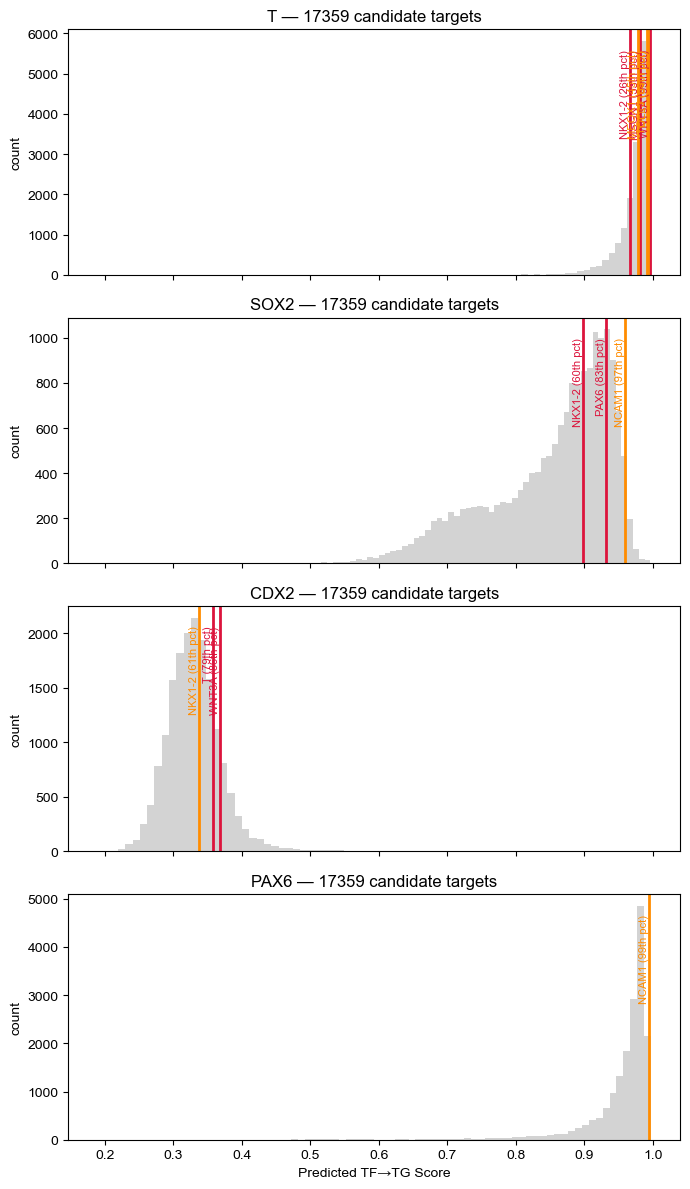

In [ ]:
curated_tfs = curated_edge_df["Source"].unique().tolist()
tier_colors = {"core": "crimson", "pathway": "darkorange"}

fig, axes = plt.subplots(
    len(curated_tfs), 1,
    figsize=(7, 3 * len(curated_tfs)),
    sharex=True,
)
axes = np.atleast_1d(axes)

for ax, tf in zip(axes, curated_tfs):
    tf_scores = tf_target_scores[tf]["Score"]
    ax.hist(tf_scores, bins=60, color="lightgray", edgecolor="none")

    tf_edges = curated_results_df[curated_results_df["Source"] == tf]
    for _, edge in tf_edges.iterrows():
        color = tier_colors[edge["tier"]]
        ax.axvline(edge["Score"], color=color, linewidth=2)
        ax.text(
            edge["Score"], ax.get_ylim()[1] * 0.92,
            f"{edge['Target']} ({edge['percentile']:.0f}th pct)",
            rotation=90, va="top", ha="right",
            fontsize=8, color=color,
        )

    ax.set_title(f"{tf} — {len(tf_scores)} candidate targets")
    ax.set_ylabel("count")

axes[-1].set_xlabel("Predicted TF→TG Score")
plt.tight_layout()
plt.show()

### Mini-AUPRC: curated edges vs. sampled negatives

Same idea as the project's main AUPRC benchmark (`TETHER/docs/auprc_calculation_method.md`), scaled down to the curated NMP edge set: pool all candidate targets of the 4 curated TFs, label the curated edges as positives, sample negatives at 10x the positive count (`random_state=42`, matching the convention used there), and score with average precision. Lift over the random baseline (= positive rate in the sampled set) is the useful number here since n is small.

Positives: 13 / candidate universe: 69436


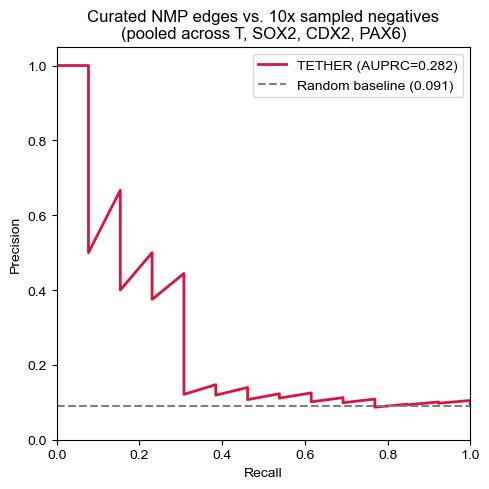

AUPRC = 0.282, baseline = 0.091, lift = 3.10x


In [ ]:
from sklearn.metrics import average_precision_score, precision_recall_curve

candidate_universe = prediction_df[
    prediction_df["Source"].isin(curated_edge_df["Source"])
].copy()

positive_pairs = set(zip(curated_edge_df["Source"], curated_edge_df["Target"]))
candidate_universe["is_curated"] = [
    (s, t) in positive_pairs
    for s, t in zip(candidate_universe["Source"], candidate_universe["Target"])
]

n_pos = int(candidate_universe["is_curated"].sum())
print(f"Positives: {n_pos} / candidate universe: {len(candidate_universe)}")

# Sample negatives at 10x positives, mirroring sample_auprc_10x_negatives
# in plot_auprc_all_methods.py, so the PR curve isn't drowned out by the
# ~17k non-curated targets per TF
neg_pool = candidate_universe[~candidate_universe["is_curated"]]
sampled_negs = neg_pool.sample(
    n=min(len(neg_pool), n_pos * 10),
    random_state=42,
)

eval_df = pd.concat([
    candidate_universe[candidate_universe["is_curated"]],
    sampled_negs,
]).reset_index(drop=True)

auprc = average_precision_score(eval_df["is_curated"], eval_df["Score"])
baseline = eval_df["is_curated"].mean()
precision, recall, _ = precision_recall_curve(eval_df["is_curated"], eval_df["Score"])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(recall, precision, color="crimson", linewidth=2, label=f"TETHER (AUPRC={auprc:.3f})")
ax.axhline(baseline, color="gray", linestyle="--", label=f"Random baseline ({baseline:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curated NMP edges vs. 10x sampled negatives\n(pooled across T, SOX2, CDX2, PAX6)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

print(f"AUPRC = {auprc:.3f}, baseline = {baseline:.3f}, lift = {auprc / baseline:.2f}x")